## CSCI-4041 - Algorithms - Chapter 6

## Array-based Trees

### Joy Upton Azzam

### 2/13/2026

<mark>_____________________________________________________________________________________</mark>

### 1. Array Based Binary Tree


<div style="width:75%; margin: auto;">

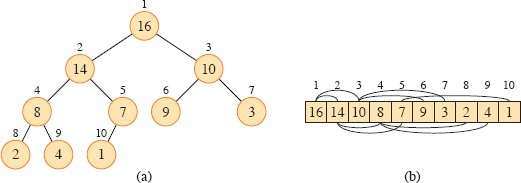

</div>

In [ ]:
class arraytree:
    """an array-based binary tree"""

    def __init__(self,n,A=None):
        """constructor for array-based binary trees"""
        if A:
            self.A = A
            self.size = n
        else:
            self.A = [None for i in range(n)]
            self.size = 0
        self.capacity = n

    def add_root(self,k):
        """adds key k as root of the tree, returning the index"""
        if self.size == 0:
            self.A[0] = k
            self.size = 1
            return 0
    
    def add_left(self,p,k):
        """adds key k as the left child of node p"""        
        if p < self.capacity and self.A[p] is not None:
            l = self.left(p)           # left child index
            if l < self.capacity:      # check if there is room
                self.A[l] = k
                self.size += 1
            return l               # return index of the new node
    
    def add_right(self,p,k):
        """adds key k as the left child of node p"""        
        if p < self.capacity and self.A[p] is not None:
            r = self.right(p)         # right child index
            if r < self.capacity:     # check if there is room
                self.A[r] = k
                self.size += 1
            return r              # return index of the new node

    def delete(self,x):
        """deletes node x (if it has no children)"""
        l = self.left(x)     # left child index
        r = self.right(x)    # right child index
        
        if l < self.capacity and self.A[l] == None:
            if r < self.capacity and self.A[r] == None:
                self.A[x] = None
                self.size -= 1
            elif r >= self.capacity:
                self.A[x] = None
                self.size -= 1
            else:
                print("node",x,"is not a leaf")
        else:
            print("node",x,"is not a leaf")
    
    def left(self,i):
        """returns the index of the left child in a complete array-based tree"""
        return 2*i + 1
    
    def right(self,i):
        """returns the index of the right child in a complete array-based tree"""
        return 2*i + 2
    
    def parent(self,i):
        """returns the index of the parent in a complete array-based tree"""
        return (i-1)//2

<mark>_____________________________________________________________________________________</mark>

### 2. Printing Utility Functions for Array-based Trees

In [27]:
def get_coordinatesArray(T):
    """traverses a binary linked tree in-order computing the coordinates and saving information as needed"""
    
    def in_order(T,node,depth):
        """in-order traversal of the array-based tree"""
        nonlocal x,coords
        
        l = T.left(node)     # left child index
        r = T.right(node)    # right child index
        
        if l < T.capacity:       # if there are more nodes
            in_order(T,l,depth+1)    # traverse to the left
        
        #------------------------in-order actions--------------------------------------
        # coordinate data[breadth-first index] =   (  in-order # , depth , key , parent (BFS) index )
        coords[node] = (x,-depth,T.A[node],T.parent(node))    # save data
        x += 1
        #------------------------------------------------------------------------------
        
        if r < T.capacity:       # if there are more nodes to the right
            in_order(T,r,depth+1)    # traverse to the right
    
    x = 0
    coords = [None for i in range(T.capacity)]
    
    in_order(T,0,0)
    
    return coords

In [63]:
import matplotlib.pyplot as plt


def PrintTreeArray(T,scale=0.5,node_size=500,font=12):
    """Creates a scatter plot of a binary linked tree"""
    
    fig, ax = plt.subplots()            # create image (figure/axis) object
    
    coords = get_coordinatesArray(T)         # call recursive coordinate code

    b = 0.75 # outer border for image
    ax.set_xlim([-b, len(coords)])    # set the image frame (axis) limits
    ax.set_ylim([min([data[1] for data in coords if data[2] is not None])-b, b])

    for data in coords:                 # loop over the coordinate data
        x,y,key,parent = data           # extract tuple data
        if key is not None:
            # Plot the point for the node
            ax.scatter([x],[y],s=node_size,zorder=2,color="olive")
            
            # Add the annotation for the text of the nodes key
            ax.annotate(str(key), xy=(x,y), xytext=(x,y), 
                        fontsize=font, ha='center',va='center',zorder=3)
            
            # Add the lines for parent child-relationship
            if parent >= 0:
                px,py = coords[parent][0:2] # parents coordinates (based on idx above)
                ax.annotate("",
                        xy=(px,py), xytext=(x,y),
                        arrowprops=dict(arrowstyle="-",connectionstyle="arc3",color="darkgoldenrod")
                       ,zorder=1)
    
    plt.gcf().set_size_inches(16*scale, 9*scale)    # set figure size
    plt.show()                                      # display the figure

<mark>_____________________________________________________________________________________</mark>

### 3. Example Code / Usage

In [67]:
T = arraytree(16)

p = T.add_root(1)

left = T.add_left(p,2)
right = T.add_right(p,3)

one = T.add_left(left,4)
two = T.add_right(left,5)

three = T.add_left(right,6)
four = T.add_right(right,7)

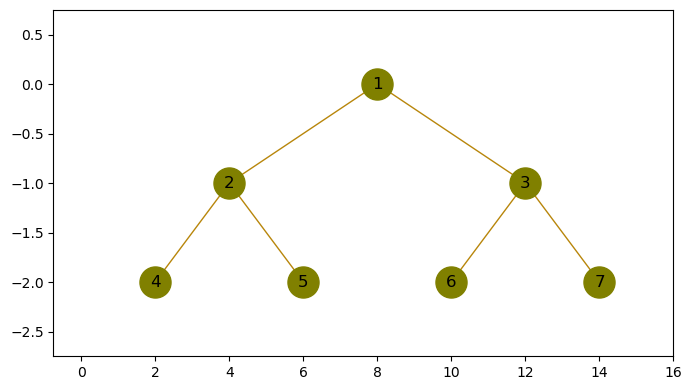

In [69]:
PrintTreeArray(T)

node 0 is not a leaf


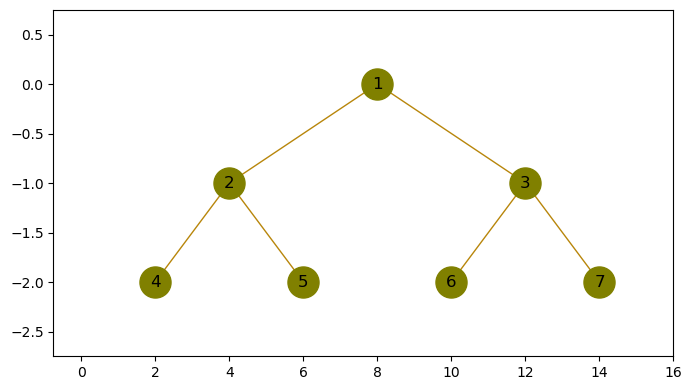

In [71]:
T.delete(0)
PrintTreeArray(T)

node 1 is not a leaf


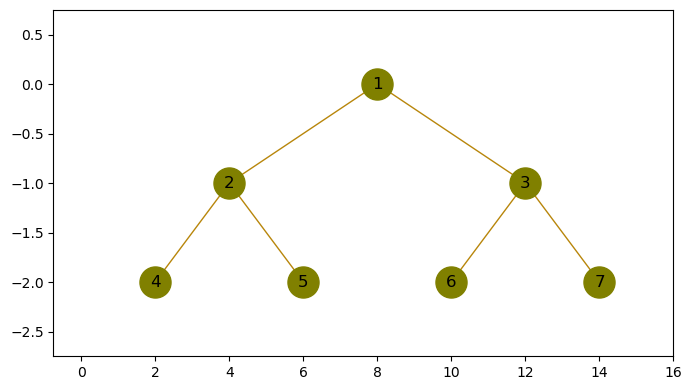

In [73]:
T.delete(1)
PrintTreeArray(T)

node 2 is not a leaf


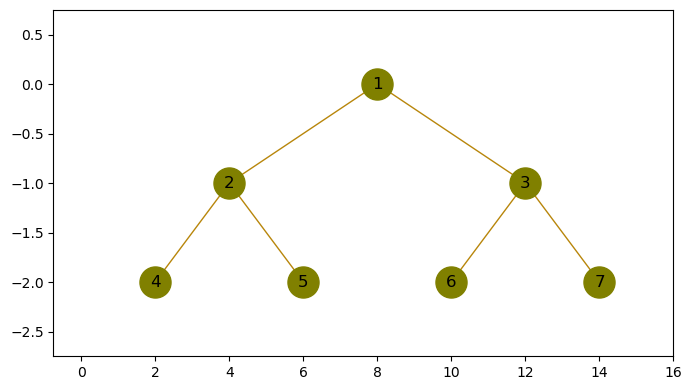

In [74]:
T.delete(2)
PrintTreeArray(T)

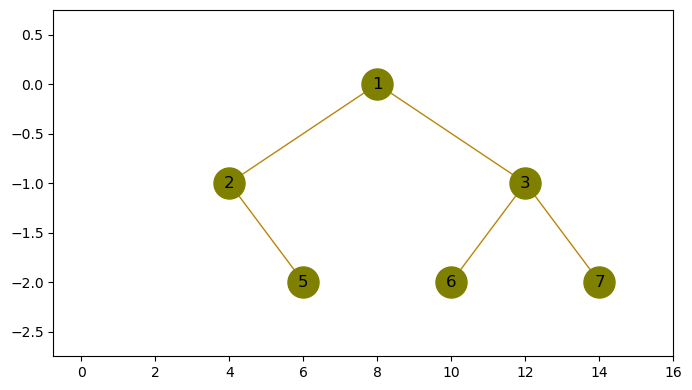

In [77]:
T.delete(3)
PrintTreeArray(T)

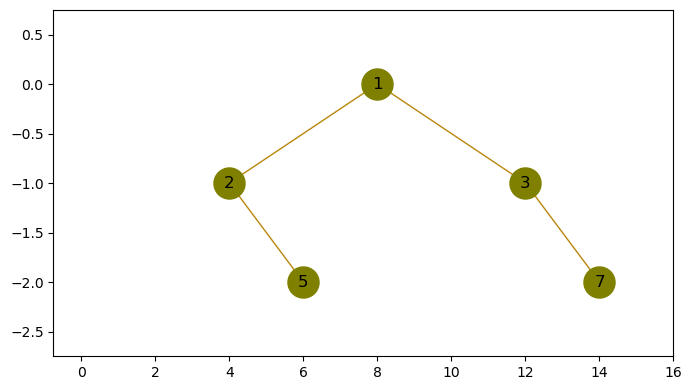

In [79]:
T.delete(5)
PrintTreeArray(T)